In [1]:
from smode_import import *
bathy = xr.open_dataset('~/data/GEBCO_2020.nc')
SMODE_data = '/Users/elise/data/SMODE-data/'

In [2]:
from scipy.spatial.distance import cdist
# compute distance between 2 pairs of coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance #in km

In [3]:
#uw = xr.open_dataset('/Users/elise/ocean/drifters_chl/SMODE-data/TSG/IOP2_Underway_Data.nc')
#uw

In [6]:
# load underway ship data in data Array
from datetime import datetime, timedelta

ship_folder = SMODE_data+'TSG/'

# underway data
uw_time = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['time'][0][0].flatten()
uw_lat  = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['lat'][0][0].flatten()
uw_lon  = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['lon'][0][0].flatten()
uw_chl  = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['chl1'][0][0].flatten()
uw_temp = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['CT_bow'][0][0].flatten()
uw_salt = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['SA_bow'][0][0].flatten()
uw_rho  = scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['Sig0_bow'][0][0].flatten()
uw_o2sat= scipy.io.loadmat(ship_folder+'IOP2_Underway_Data.mat')['MET']['O2_sat'][0][0].flatten()

# create time array
time_array=[]
for i in range(len(uw_time)):
    matlab_datenum=uw_time[i]
    python_datetime = datetime.fromordinal(int(matlab_datenum)) + timedelta(days=matlab_datenum%1) - timedelta(days = 366)
    time_array.append(np.datetime64(python_datetime))
    
# Create Underwary DataArray
coords = {'time': time_array}
dims   = ['time']

da_lat  = xr.DataArray(uw_lat, coords=coords, dims=dims, attrs={'long_name': 'latitude',  'units': 'degrees'})
da_lon  = xr.DataArray(uw_lon, coords=coords, dims=dims, attrs={'long_name': 'longitude', 'units': 'degrees'})
da_chl  = xr.DataArray(uw_chl,   coords=coords, dims=dims, attrs={'long_name': 'Chlorophyll Concentration', 'units': 'mg m-3'})
da_temp = xr.DataArray(uw_temp,  coords=coords, dims=dims, attrs={'long_name': 'Temperature', 'units': 'Celsius'})
da_salt = xr.DataArray(uw_salt,  coords=coords, dims=dims, attrs={'long_name': 'Salinity', 'units': 'psu'})
da_rho  = xr.DataArray(uw_rho,   coords=coords, dims=dims, attrs={'long_name': 'Density', 'units': 'kg m-3'})
da_o2sat= xr.DataArray(uw_o2sat, coords=coords, dims=dims, attrs={'long_name': 'Oxygen Saturation', 'units': '%'})


underway_data = xr.Dataset({
    'lat': da_lat,
    'lon': da_lon,
    'chl': da_chl,
    'temp': da_temp,
    'salt': da_salt,
    'rho': da_rho,
    'o2sat': da_o2sat
})
underway_data

#underway_data.to_netcdf('/Users/elise/data/SMODE-data/TSG/IOP2_underway.nc',mode='w')


In [8]:
# Drifter data
from scipy.interpolate import interp1d

drifters_folder = '/Users/elise/data/SMODE-data/drifters/2023/'
dr=sorted(glob(drifters_folder+'SMODE_IOP2_surface_drifter_0*.nc'))
if len(dr)==0: print('no files found')

# Satellite data
sat_chl = xr.open_dataset('/Users/elise/data/AQUA_MODIS_YEARLY/chla-2023.nc')

def is_night(timestamp): #account for photochemical quenching
    return (timestamp.dt.hour < 9) | (timestamp.dt.hour >= 17)

# Loop over drifters   
for i in range(len(dr)):
    # ----- Ship chlorophyll at drifter location -------
    drift=xr.open_dataset(dr[i])# Open one drifter file
    keep = drift.position_QCflag==1 #keep good data
    time,lat,lon = drift.time[keep],drift.latitude[keep],drift.longitude[keep]

    # Interpolate ship data onto drifter time
    numeric_uw_time = underway_data.time.astype('int64') / 1e9 # Convert datetime64 to numeric representation for interpolation
    numeric_drifter_time = time.astype('int64') / 1e9  # Convert nanoseconds to seconds
    # interpolate longitude
    interp_function = interp1d(numeric_uw_time, underway_data.lon, kind='linear', 
                               fill_value=np.nan, bounds_error=False)
    interp_lon = interp_function(numeric_drifter_time)
    # interpolate latitude
    interp_function = interp1d(numeric_uw_time, underway_data.lat, kind='linear', 
                               fill_value=np.nan, bounds_error=False)
    interp_lat = interp_function(numeric_drifter_time)
    # interpolate chlorophyll
    interp_function = interp1d(numeric_uw_time, underway_data, kind='linear', 
                               fill_value=np.nan, bounds_error=False)
    interp_chl = interp_function(numeric_drifter_time)
    # Calculate pairwise distances
    distances = haversine(lat, lon, interp_lat, interp_lon)

    # Save chlorophyll values when dist < 1 km  & nighttime
    idx = (distances <= 1) & (is_night(time))
    chl_drift= lon.copy()*np.nan
    chl_drift[idx] = interp_chl[idx]
    time_keep=time[idx]
    chl_ship_at_drifter = interp_chl[idx]
    
    dChldt_ship = np.diff(chl_ship_at_drifter)

    # ---satellite chlorophyll at drifter location ---
    # sentinel 3a
    '''
    sat_chl = xr.open_dataset('~/ocean/drifters_chl/SMODE-data/sen3_2023_gridded.nc')
    sat_chl_at_drifter=np.empty(len(sat_chl.time))
    for it in range(sat_chl.dims['time']):
        Slat=lat.sel(time=sat_chl.time[it],method='nearest')
        Slon=lon.sel(time=sat_chl.time[it],method='nearest')
        sat_chl_at_drifter[it]=sat_chl.chl.isel(time=it).sel(lat=Slon,lon=Slon,method='nearest')
    # convert value
    add_offset, scale_factor = -2., 0.01574803
    sat_chl_at_drifter = (sat_chl_at_drifter - add_offset) / scale_factor
    sat_chl_at_drifter = np.exp(sat_chl_at_drifter)
    '''
    # ---------- plot drifter map ------------------
    
    #fig,ax=plt.subplots(1,1,figsize=(4,4))
    plt.figure()
    ax = plt.axes(projection=ccrs.PlateCarree())

    # bathymetry and coastline
    #bathy.elevation.sel(lat=slice(30,40),lon=slice(-128,-120)).plot(ax=ax)
    ax.coastlines()
    smode_pgon(ax)

    # chlorophyll and drifter
    s=40
    cmap='Greens'
    ax.plot(lon,lat,'-k')
    #drift_scatter= ax.scatter(lon[::50], lat[::50], s=s/10, facecolor='None', edgecolor='k', alpha=0.3, linewidth=0.5)
    chl_scatter  = ax.scatter(lon[idx], lat[idx], s=s, c=chl_ship_at_drifter, 
                              cmap=cmap, edgecolor='k', vmin=0, vmax=3.5,zorder=111)
    
    # figure properties
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Drifter {drift.drifter_id[2:]}')
    cbar = plt.colorbar(chl_scatter,shrink=0.6)
    cbar.set_label('Chl [mg m-3]')
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='k', alpha=0.0, linestyle='-')
    gl.top_labels = False
    gl.right_labels = False

    ax.set_xlim(-126.5,-121)
    ax.set_ylim(35,38.5)
    
    #plt.savefig(f'drifter_ship_chl/drifter_ship_chl_{drift.drifter_id[2:]}.png',dpi=800)
    plt.show();

    # ---------- plot time series --------------------
    
    plt.figure(figsize=(12,2))
    #plt.plot(sat_chl.time,sat_chl_at_dritfer,'og',markersize=5,label='satellite')
    plt.plot(time_keep[1::],dChldt_ship,'vk',label='ship')
    plt.ylabel('d(Chl)/dt [mg m-3 s-1]')
    plt.xticks(rotation=25)
    plt.grid(alpha=0.2)
    #plt.ylim(0,4)
    plt.title(f'Drifter {drift.drifter_id[2:]}')
    plt.legend()
    plt.show();
    

TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

In [ ]:
#chl=xr.open_dataset('/Users/elise/Desktop/AQUA_MODIS.20230422.L4m.DAY.AVW.avw.4km.nc')
#chl
#fig,ax=plt.subplots(1,1)
#chl.plot(ax=ax)
#smode_pgon(ax)

In [10]:
def interp_ship_on_drifter(underway_data, drifter):
    # drifter data
    time_dr= drifter.time
    lat_dr = drifter.latitude
    lon_dr = drifter.longitude

    def is_night(timestamp,delta): #account for photochemical quenching
        # UTC to PST delta=-7
        return (timestamp.dt.hour < 9-delta) | (timestamp.dt.hour >= 17-delta)
    
    def interpolate_function(time_dr,time_uw,variable):
        num_time_uw      = time_uw.astype('int64') / 1e9 # nanoseconds to seconds
        num_time_drifter = time_dr.astype('int64') / 1e9
        interp_function  = interp1d(num_time_uw, variable, kind='linear',fill_value=np.nan, bounds_error=False)
        interpolated_data= interp_function(num_time_drifter)
        return interpolated_data
        
    # Interpolate ship data onto drifter time
    interp_lon = interpolate_function(time_dr,underway_data.time,underway_data.lon)
    interp_lat = interpolate_function(time_dr,underway_data.time,underway_data.lat)
    interp_chl = interpolate_function(time_dr,underway_data.time,underway_data.chl)
    interp_temp = interpolate_function(time_dr,underway_data.time,underway_data.temp)
    interp_salt = interpolate_function(time_dr,underway_data.time,underway_data.salt)
    interp_rho = interpolate_function(time_dr,underway_data.time,underway_data.rho)
    interp_o2sat = interpolate_function(time_dr,underway_data.time,underway_data.o2sat)
    
    # Save chlorophyll values when dist < 1 km  & nighttime
    distances = haversine(lat_dr, lon_dr, interp_lat, interp_lon) # pairwise distances
    idx = (distances <= 1) & (is_night(time_dr,delta=-7))

    # Output data
    time_at_drifter = time_dr[idx]
    lon_at_drifter  = lon_dr[idx]
    lat_at_drifter  = lat_dr[idx]
    
    chl_ship_at_drifter = interp_chl[idx]
    temp_ship_at_drifter = interp_temp[idx]
    salt_ship_at_drifter = interp_salt[idx]
    rho_ship_at_drifter = interp_rho[idx]
    o2sat_ship_at_drifter = interp_o2sat[idx]

    dataset = xr.Dataset(
    {
        'lon': ('time', lon_dr[idx].values),
        'lat': ('time', lat_dr[idx].values),
        'chl': ('time', interp_chl[idx]),
        'temp': ('time', interp_temp[idx]),
        'salt': ('time', interp_salt[idx]),
        'rho': ('time', interp_rho[idx]),
        'o2sat': ('time', interp_o2sat[idx]),
    },
    coords={'time': time_dr[idx].values}
)
    
    return dataset
    

In [11]:
drifters_folder = 'drifters/2023/'

dr=sorted(glob(SMODE_data+drifters_folder+'SMODE_IOP2_surface_drifter_0*.nc'))
if len(dr)==0: print('no files found')

# Loop over drifters
dChldt_ship_ALL = []
time_ALL = []
lat_ALL = []
lon_ALL = []
for i in range(len(dr)):
    # open drifter
    drifter=xr.open_dataset(dr[i])

    # find ship chlorophyll value at drifter
    ds = interp_ship_on_drifter(underway_data,drifter)
    chl_ship_at_drifter = ds.chl
    time = ds.time
    lat  = ds.lat
    lon  = ds.lon
    
    # dChl/dt
    dChl = np.diff(chl_ship_at_drifter) # mg m-3
    dt   = (time.diff(dim='time')*1e-9).astype(float) # seconds
    dChldt_ship = dChl/dt

    # remove outliers +/3 3e-3 mg m-3 s-1
    condition = np.where(np.abs(dChldt_ship)<3e-3)[0]
    
    # save all data
    dChldt_ship_ALL.append(dChldt_ship[condition])
    time_ALL.append(time[1::][condition])
    lat_ALL.append(lat[1::][condition])
    lon_ALL.append(lon[1::][condition])
    
dChldt_ship_ALL_array = np.concatenate(dChldt_ship_ALL,axis=0)
lat_ALL_array         = np.concatenate(lat_ALL,axis=0)
lon_ALL_array         = np.concatenate(lon_ALL,axis=0)
time_ALL_array        = np.concatenate(time_ALL,axis=0)
print(len(dChldt_ship_ALL_array),len(lon_ALL_array),len(lat_ALL_array))

415 415 415


In [13]:
# sort my data with increasing time
sorted_indices = np.argsort(time_ALL_array)[2::]
sorted_time_array = time_ALL_array[sorted_indices]
sorted_lat_array = lat_ALL_array[sorted_indices]
sorted_lon_array = lon_ALL_array[sorted_indices]
sorted_dChldt_array = dChldt_ship_ALL_array[sorted_indices]

create=0
if create==1:
    def create_dataArray(var,varname,description):
        dataArray = xr.DataArray(
                data=var,
                dims=['time'],
                coords=dict(time=sorted_time_array),
                attrs=dict(
                    description=description,
                    variable=varname,
                ),
            )
        return dataArray
    
    dataArray1=create_dataArray(sorted_dChldt_array,'dChldt','Chlorophyll rate of change [kg m-3 s-1]')
    dataArray2=create_dataArray(sorted_lon_array,'lon','longitude [degrees]')
    dataArray3=create_dataArray(sorted_lat_array,'lat','latitude [degrees]')
    
    file = xr.Dataset({'dChldt': dataArray1, 'lon': dataArray2, 'lat': dataArray3})
    file.to_netcdf('dChldt_sorted.nc')

In [37]:
ds_dChldt=xr.open_dataset('dChldt_sorted.nc')
ds_dChldt

<xarray.Dataset>
Dimensions:  (time: 402)
Coordinates:
  * time     (time) datetime64[ns] 2023-04-17T10:22:13 ... 2023-05-02T07:04:25
Data variables:
    dChldt   (time) float64 ...
    lon      (time) float64 ...
    lat      (time) float64 ...

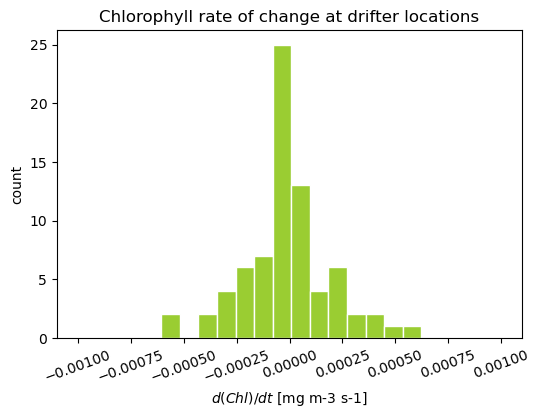

In [50]:
plt.figure(figsize=(6,4))
plt.hist(ds_dChldt.dChldt.resample(time='1H').mean(),21,edgecolor='w',color='yellowgreen')
plt.xlabel('$d(Chl)/dt$ [mg m-3 s-1]')
plt.ylabel('count')
plt.title('Chlorophyll rate of change at drifter locations',fontsize=12)
#plt.xlim(-3e-3,3e-3)
plt.xlim(-1.1e-3,1.1e-3)
plt.xticks(rotation=20)
#plt.text(1,1,dChldt_ship_ALL_array.max())
#plt.savefig('/Users/elise/ocean/drifters_chl/figures/dChldt_ALL_DRIFTERS_histogram_resampled_1H.png',dpi=800)
plt.show();

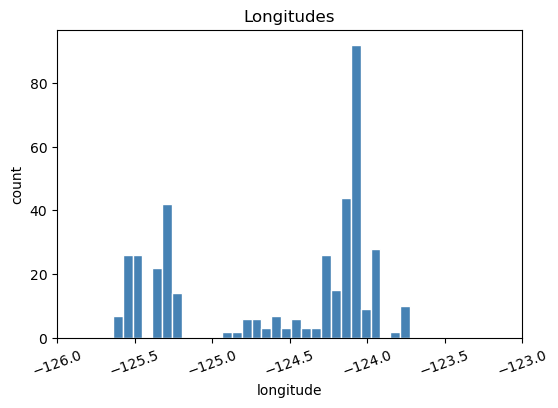

In [9]:
plt.figure(figsize=(6,4))
plt.hist(lon_ALL_array,30,edgecolor='w',color='steelblue')
plt.xlabel('longitude')
plt.ylabel('count')
plt.title('Longitudes',fontsize=12)
plt.xlim(-126,-123)
plt.xticks(rotation=20)
plt.show();

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_94419/1315909380.py:13: RuntimeWarning: Mean of empty slice
  chl_bins[i] = np.nanmean(dChldt[idx])


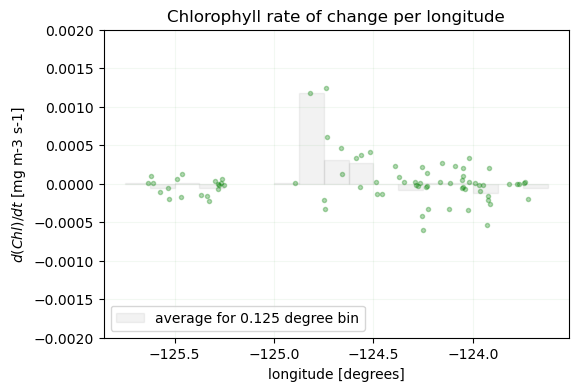

In [47]:
# compute average rate per longitude
#dChldt.resample(time='1H').mean()

lon = ds_dChldt.lon.resample(time='1H').mean()
dChldt = ds_dChldt.dChldt.resample(time='1H').mean()

bin_width=1/8
lon_bins = np.arange(-126,-123,bin_width)
chl_bins = np.empty(len(lon_bins))

for i in range(len(lon_bins)-1):
    idx = np.where((lon>=lon_bins[i]) & (lon<lon_bins[i+1]))
    chl_bins[i] = np.nanmean(dChldt[idx])

# remove last
lon_bins=lon_bins[0:-1]
chl_bins=chl_bins[0:-1]

plt.figure(figsize=(6,4))
plt.bar(lon_bins+bin_width/2, chl_bins, width=bin_width, 
        color='k',alpha=0.05,edgecolor='k',label=f'average for {bin_width} degree bin')
plt.plot(lon.values,dChldt.values,'g.',alpha=0.3)
plt.title('Chlorophyll rate of change per longitude')
plt.ylabel('$d(Chl)/dt$ [mg m-3 s-1]')
plt.ylim(-2e-3,2e-3)
plt.legend(loc='lower left')
plt.xlabel('longitude [degrees]')
plt.grid(color='g',alpha=0.05)
plt.savefig('/Users/elise/ocean/drifters_chl/figures/dChldt_per_longitude_resampled_1H.png',dpi=800)
plt.show();

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_94419/2016321516.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20)  # Rotate x-axis labels


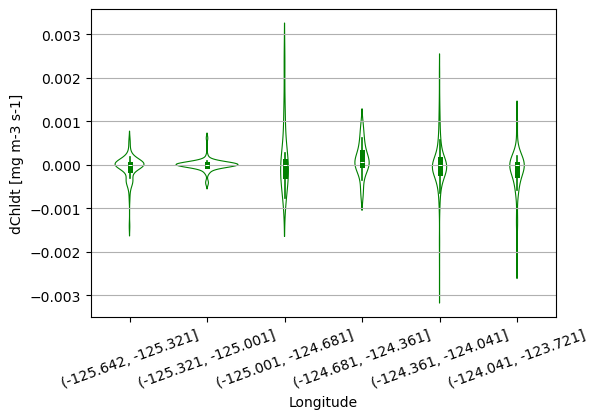

In [20]:
# Violin plot
import pandas as pd
import seaborn as sns

df = pd.DataFrame({'dChldt': dChldt_ship_ALL_array, 'lon': lon_ALL_array})
num_bins = 6 
df['lon_bins'] = pd.cut(df['lon'], bins=num_bins)

# Plot violin plot
fig,ax=plt.subplots(1,1,figsize=(6,4))
sns.violinplot(ax=ax,x='lon_bins', y='dChldt', data=df, 
               fill=False, linewidth=0.8, color='g')
ax.set_xlabel('Longitude')
ax.set_ylabel('dChldt [mg m-3 s-1]')
ax.set_title('Violin Plot of dChldt vs Longitude')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)  # Rotate x-axis labels
ax.yaxis.grid()
ax.set_title('')
#plt.savefig('/Users/elise/ocean/drifters_chl/figures/dChldt_per_longitude_violinplot.png',dpi=800)
plt.show()

In [11]:
def time_string(time):
    yyyy=time.dt.year.values
    mm=time.dt.month.values
    dd=time.dt.day.values
    h=time.dt.hour.values
    m=time.dt.minute.values
    s=time.dt.second.values
    str=f'{yyyy}-{mm:02d}-{dd:02d}'
    return str

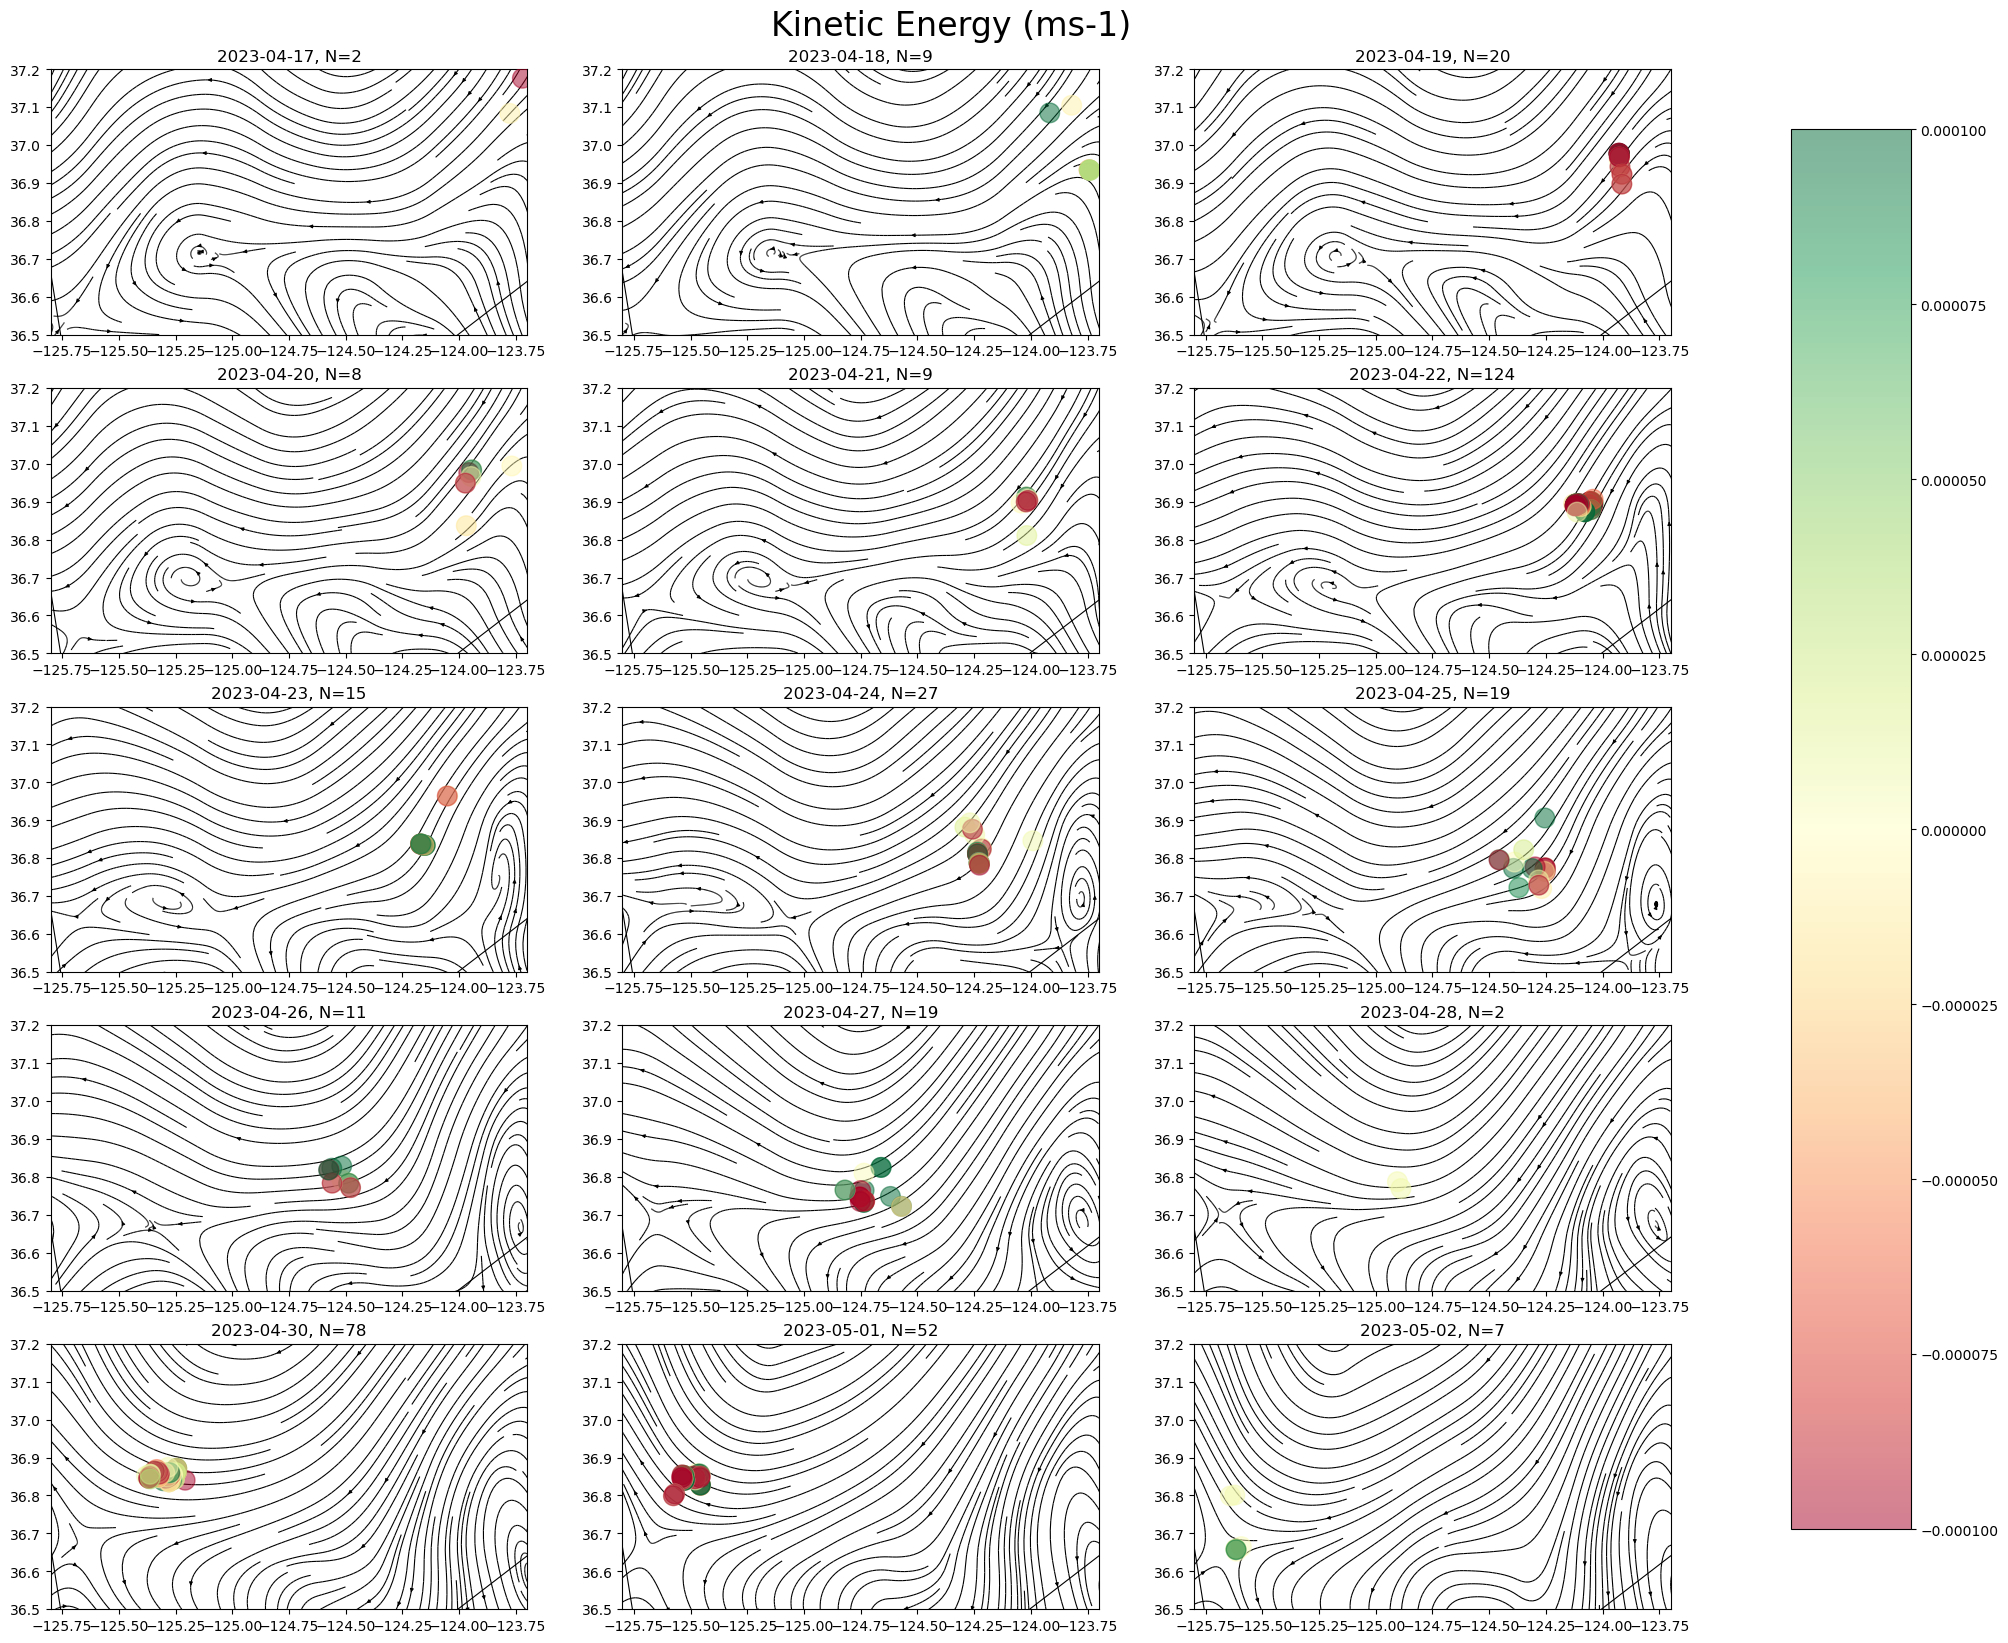

In [107]:
# Daily maps of dChl/dt drifter location w/ mesoscale field
import pandas as pd

# load mesoscale field
folder='/Users/elise/data/'
geos  = xr.open_dataset(folder+'cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_1711053566224.nc')
geos=geos.sel(latitude=slice(30,40),longitude=slice(-127,-121))
alons,alats=np.meshgrid(geos.longitude,geos.latitude)                          

# load geostrophic kinematics variables
gkin = xr.open_dataset('geostrophic_kinematics.nc')
f=gkin.f.values

# sort my data increasing time
sorted_indices = np.argsort(time_ALL_array)[2::]
sorted_time_array = time_ALL_array[sorted_indices]
sorted_lat_array = lat_ALL_array[sorted_indices]
sorted_lon_array = lon_ALL_array[sorted_indices]
sorted_dChldt_array = dChldt_ship_ALL_array[sorted_indices]

time_pd = pd.to_datetime(sorted_time_array)
fig, axes = plt.subplots(5,3,figsize=(24,20))
i=0
for day in np.unique(np.array([pd.Timestamp(date).date() for date in sorted_time_array])):
    idx_day        = pd.to_datetime(sorted_time_array).date == day
    timestamps_day = sorted_time_array[idx_day]
    lat_day        = sorted_lat_array[idx_day]
    lon_day        = sorted_lon_array[idx_day]
    dChldt_day     = sorted_dChldt_array[idx_day]
    
    # plot daily field
    # mesoscale
    day_str = f'{day.year}-{day.month}-{day.day}'
    ugos=geos.ugos.sel(time=day_str)
    vgos=geos.vgos.sel(time=day_str)
    ax=axes.flatten()[i]; i+=1
    #var=gkin.Eg.sel(time=day_str);cmap='jet';vmin,vmax=0,0.05
    #var=gkin.Sg.sel(time=day_str)/f;cmap='RdBu_r';vmin,vmax=0,0.1
    #p=var.plot.contourf(levels=50,vmin=vmin,vmax=vmax,ax=ax,cmap=cmap,add_colorbar=False)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.streamplot(alons,alats,ugos,vgos,
                       color='k',density=10,linewidth=0.8,
                       arrowsize=0.5)
    # drifter/chl location
    p=ax.scatter(lon_day, lat_day,s=200,c=dChldt_day,
                 vmin=-1e-4,vmax=1e-4,cmap='RdYlGn',
                 alpha=0.5,zorder=101)
    smode_pgon(ax); coastline(ax)
    ax.set_xlim(-126.5,-122); ax.set_ylim(35,38.5)
    ax.set_xlim(-125.8,-123.7); ax.set_ylim(36.5,37.2) #zoom
    ax.set_title(f'{day}, N={len(dChldt_day)}')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(p,cax=cbar_ax)
#plt.suptitle('Geostrophic Strain Rate (s-1)',fontsize=24,y=0.91)
plt.suptitle('Kinetic Energy (ms-1)',fontsize=24,y=0.91)
plt.show()
plt.close()

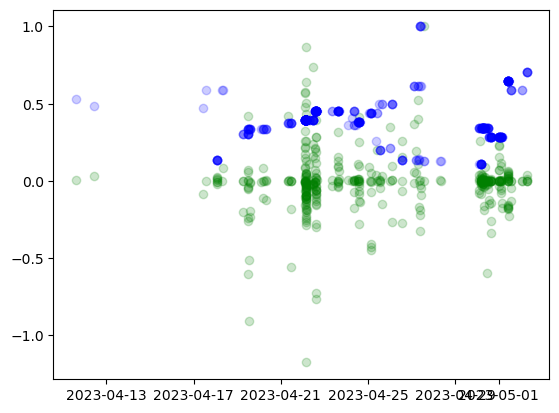

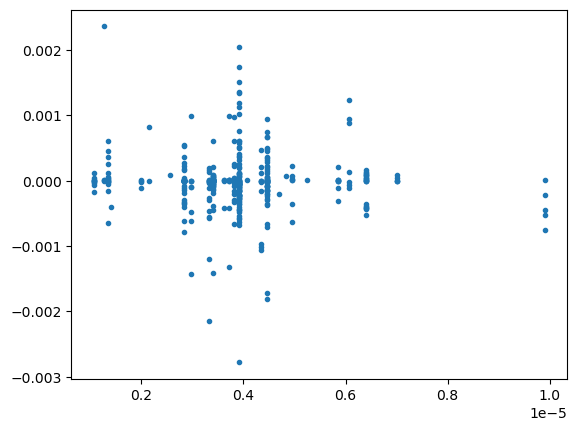

In [396]:
# time series of dChl/dt vs Eg and Sg
#sorted_dChldt_array
#sorted_lat_array
#sorted_lon_array
#sorted_time_array
    
def normalize(y):
    return y/np.max(y)

T = len(sorted_time_array)
geostrophic_array = np.empty(T)
for it in range(T):
    geostrophic_array[it]=gkin.Sg.sel(time=sorted_time_array[it],lat=sorted_lat_array[it],
                                      lon=sorted_lon_array[it],method='nearest').values
plt.figure()
plt.plot(sorted_time_array,normalize(sorted_dChldt_array),'go',alpha=0.2)
plt.plot(sorted_time_array,normalize(geostrophic_array),'bo',alpha=0.2)

plt.figure()
plt.plot(geostrophic_array,sorted_dChldt_array,'.')

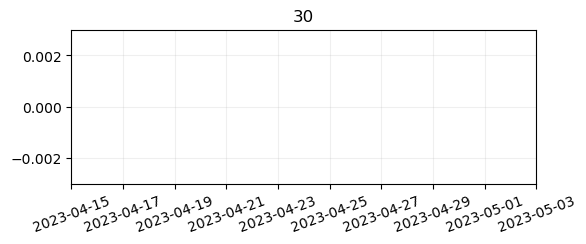

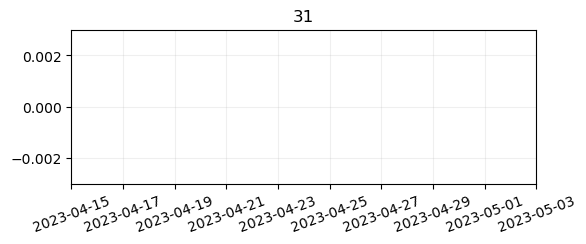

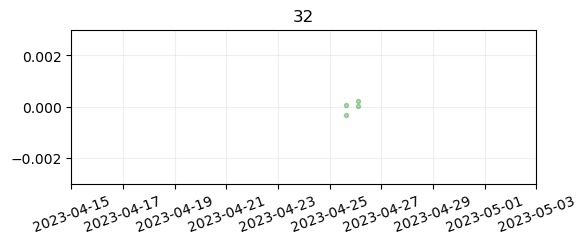

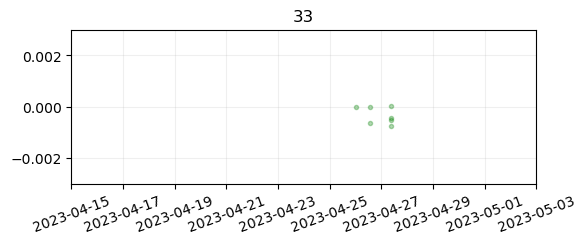

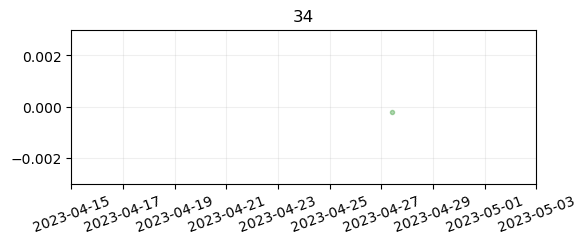

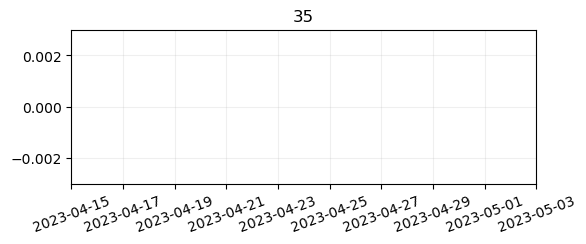

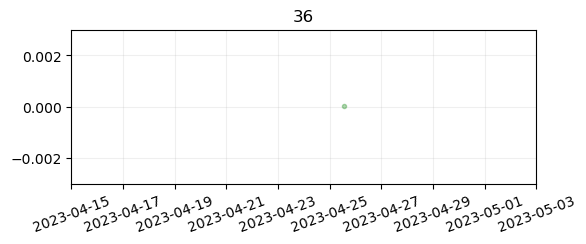

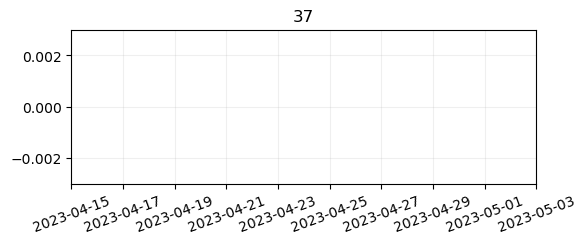

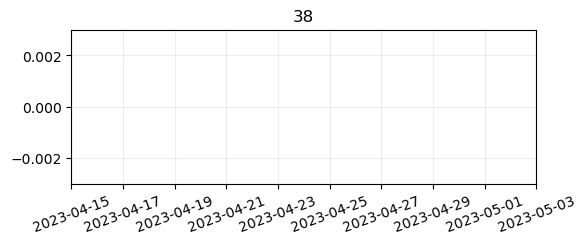

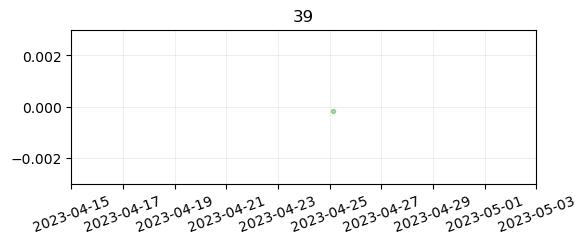

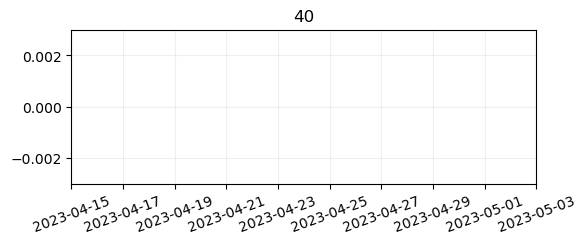

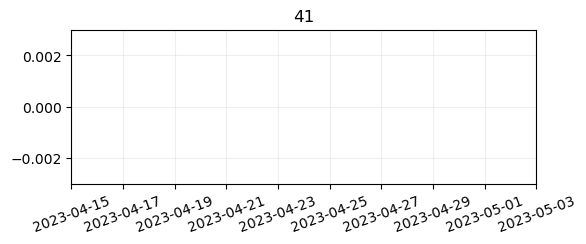

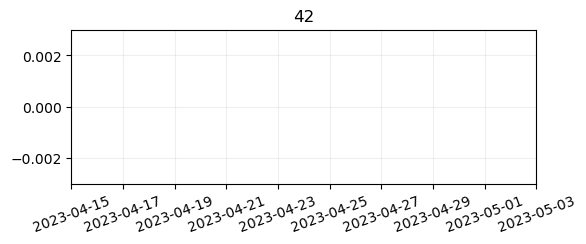

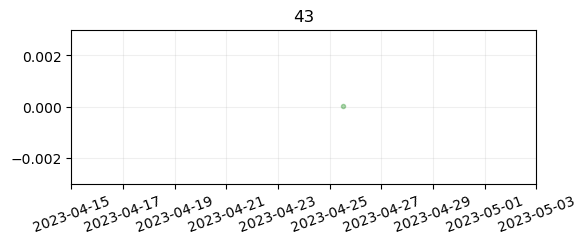

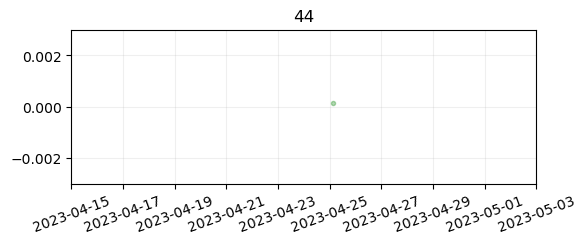

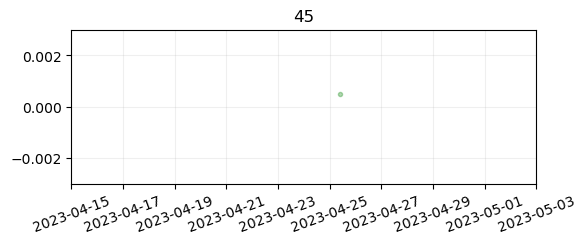

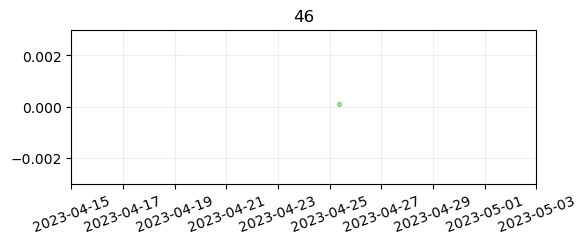

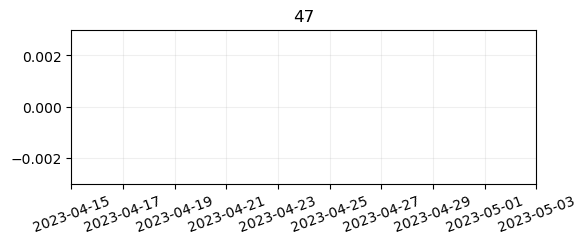

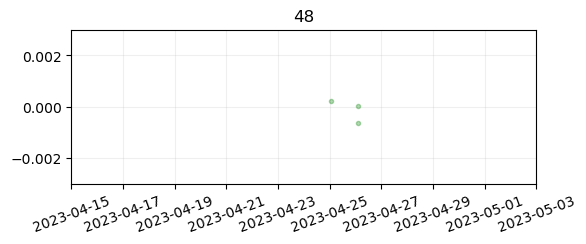

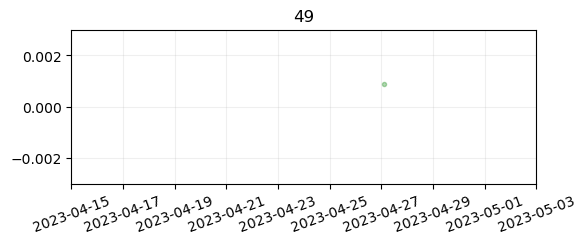

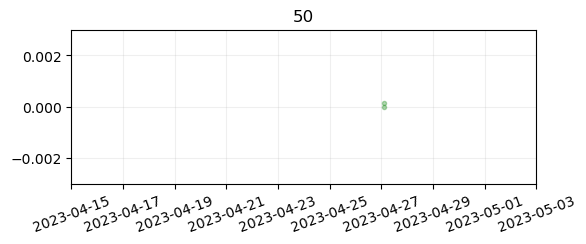

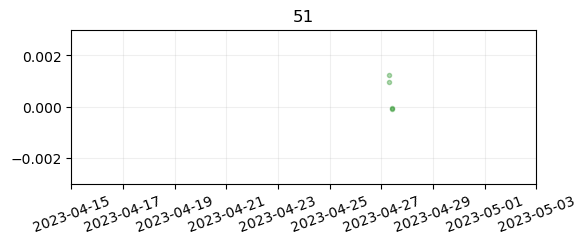

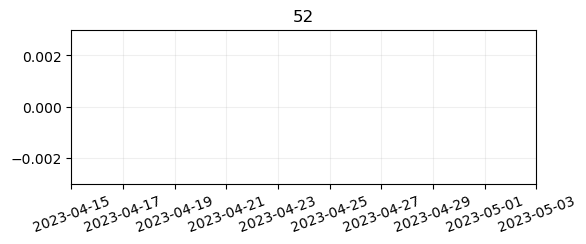

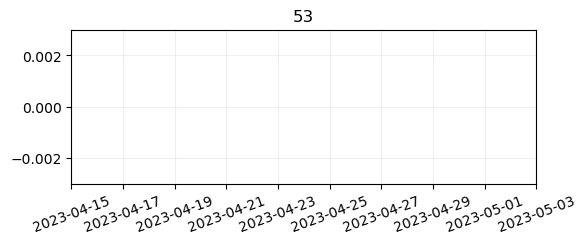

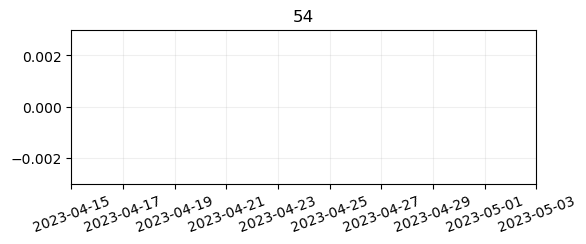

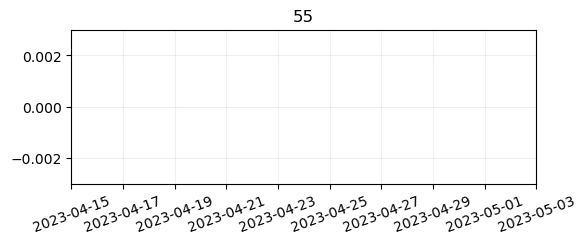

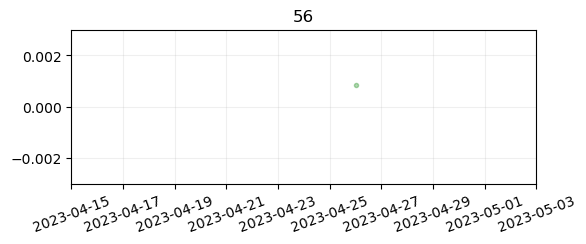

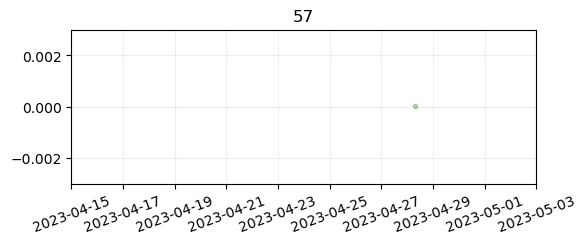

58


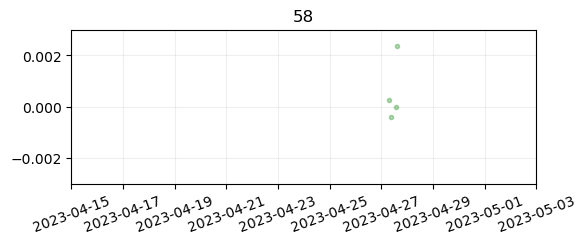

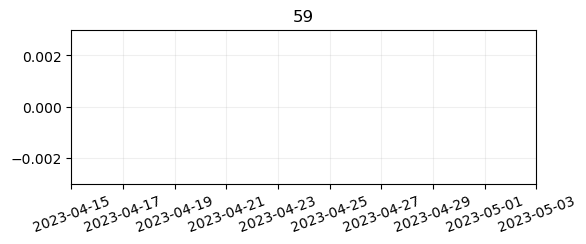

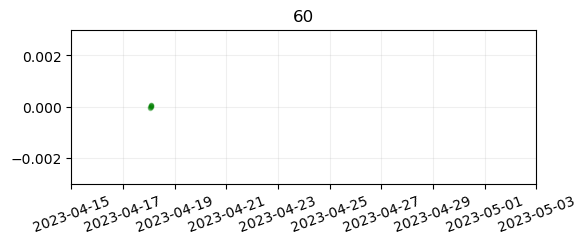

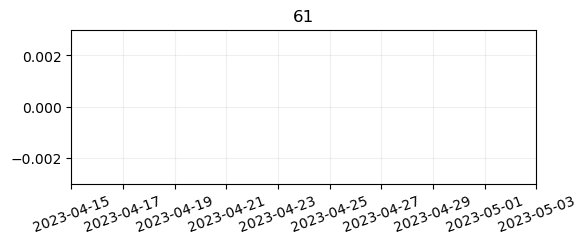

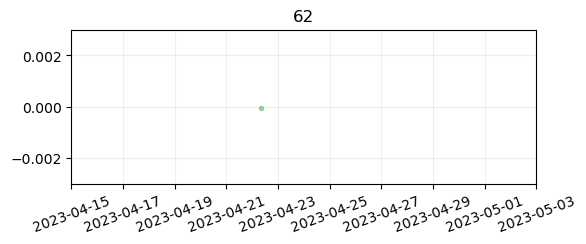

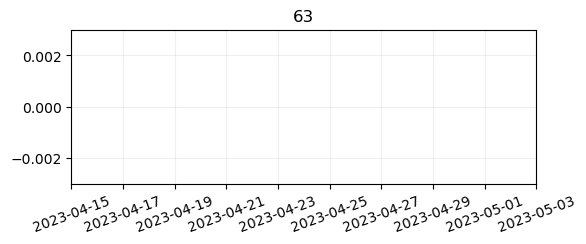

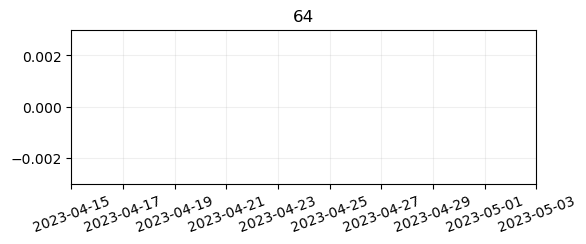

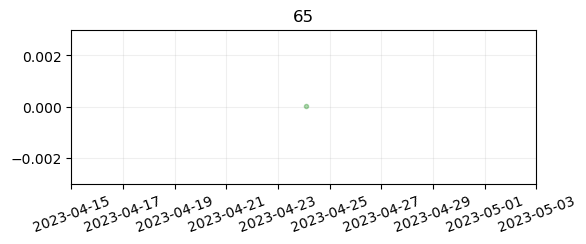

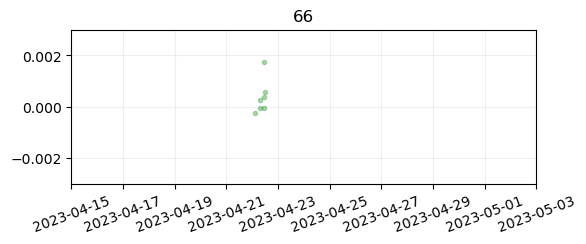

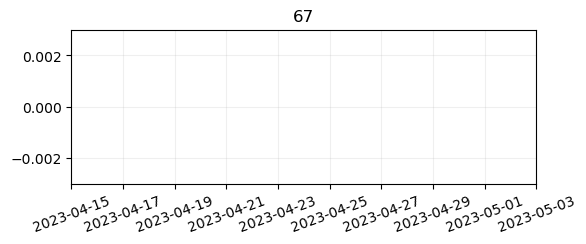

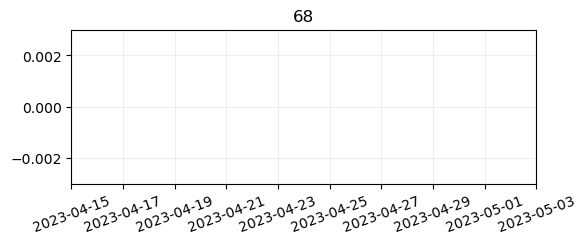

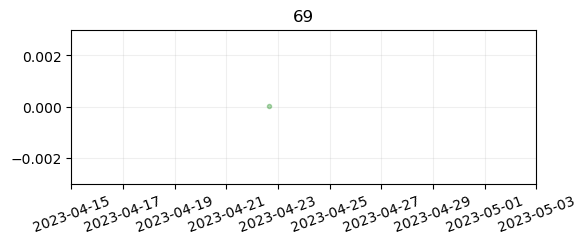

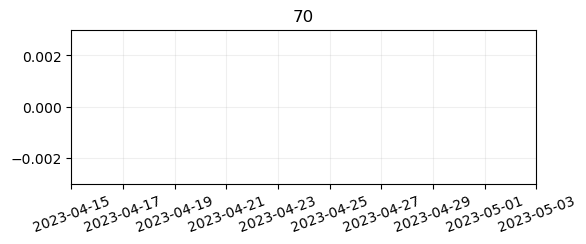

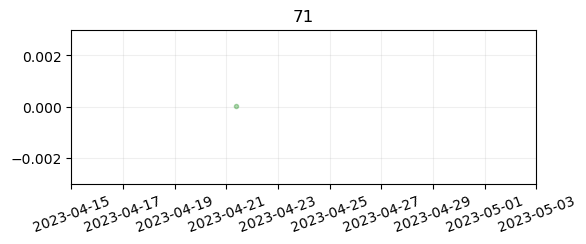

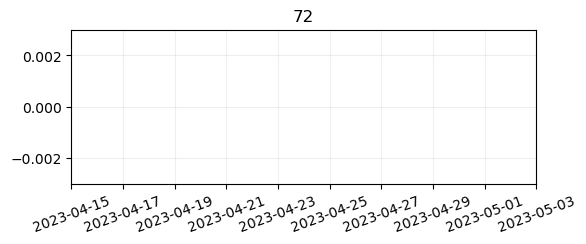

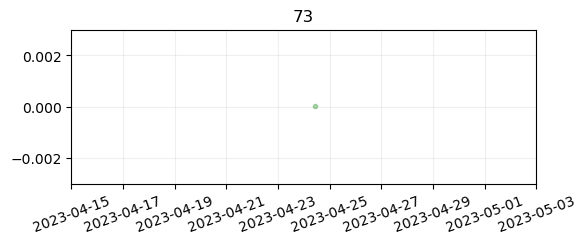

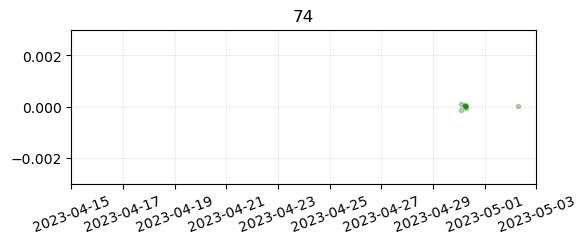

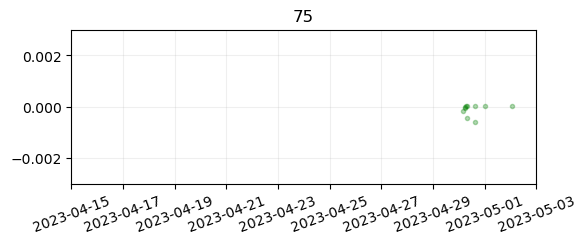

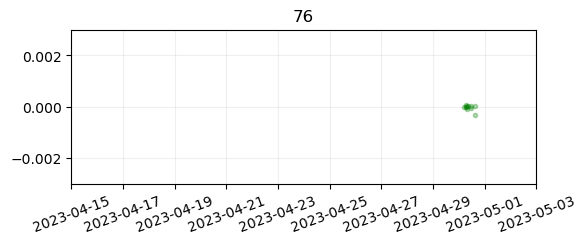

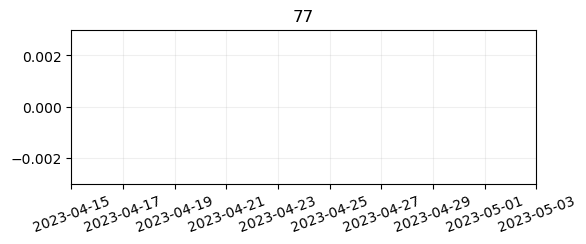

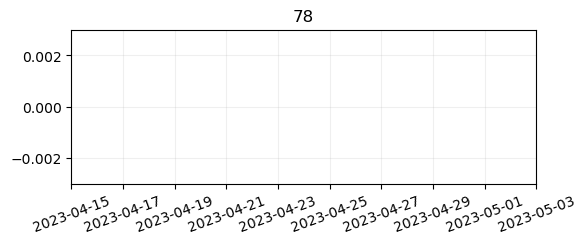

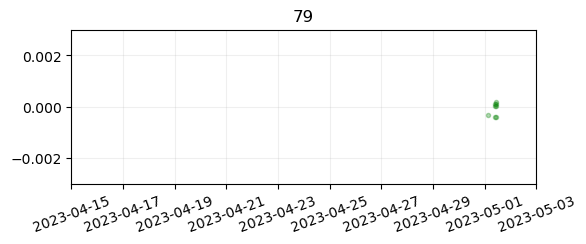

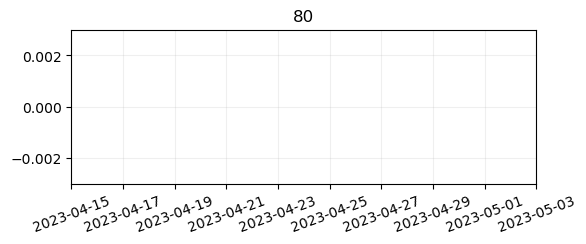

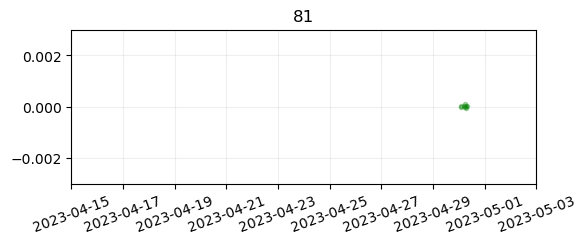

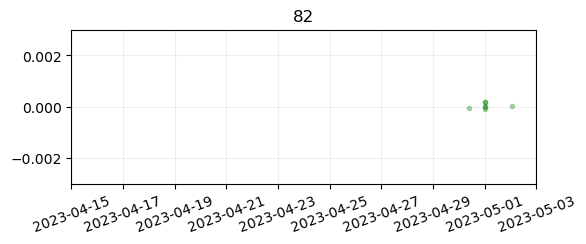

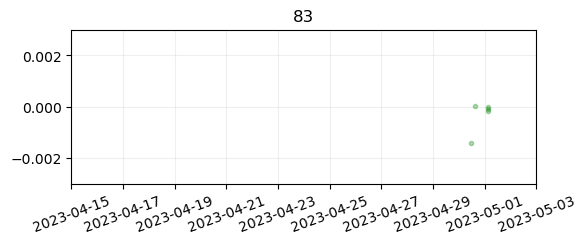

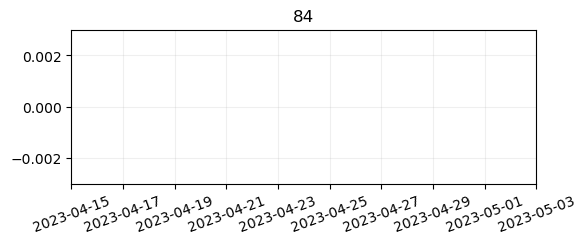

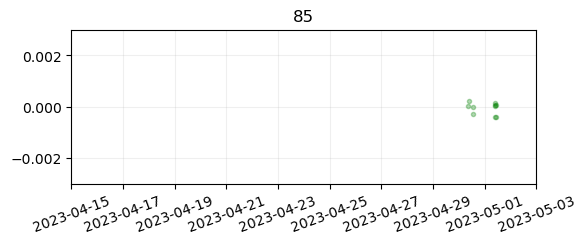

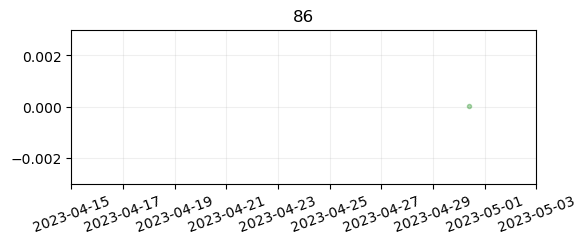

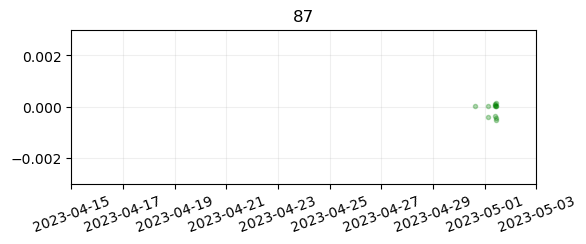

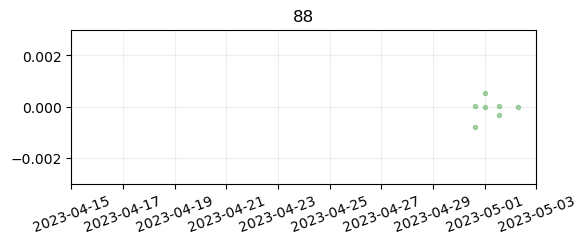

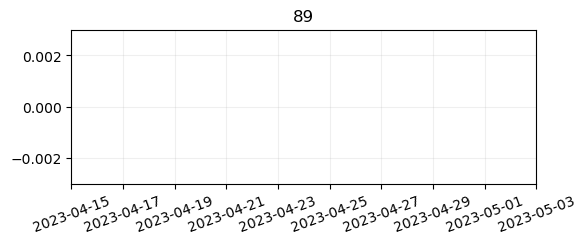

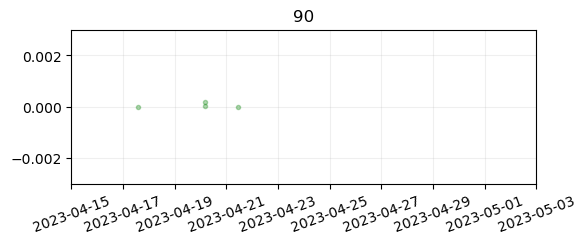

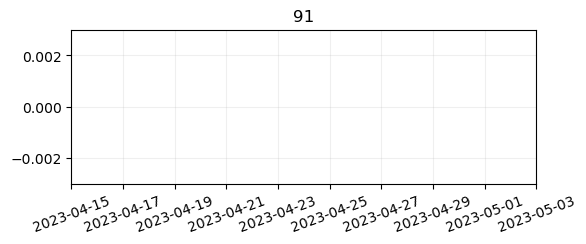

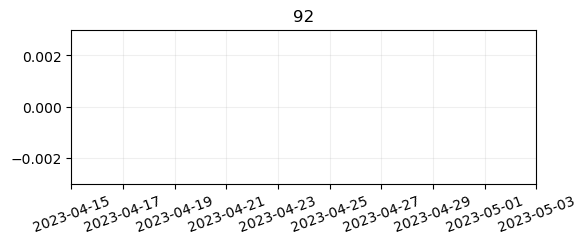

93


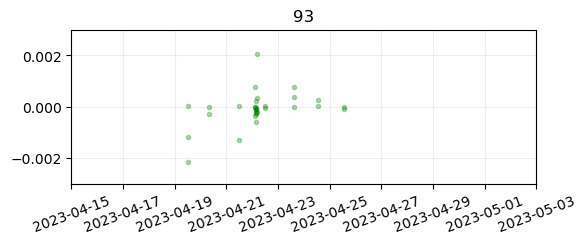

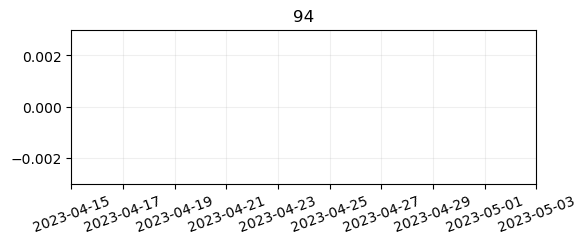

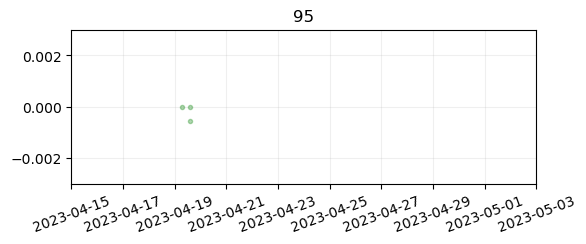

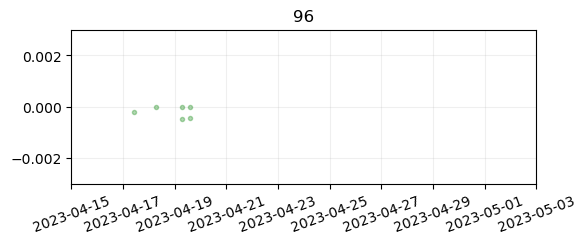

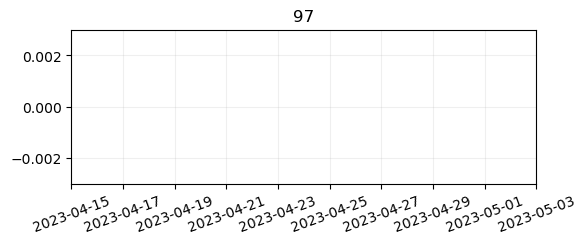

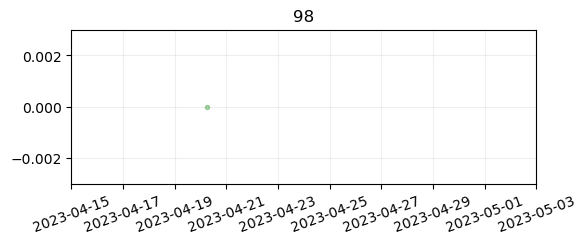

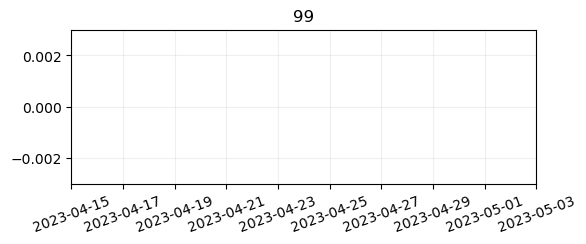

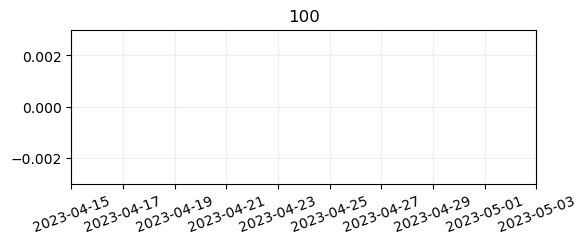

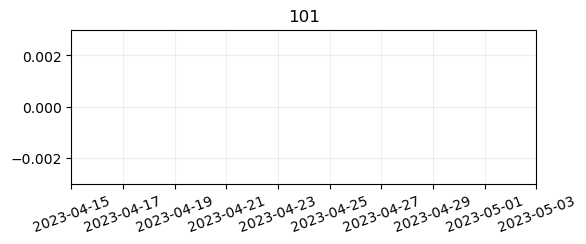

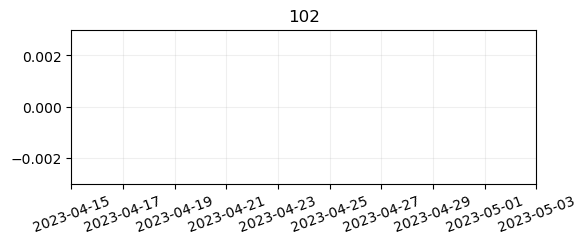

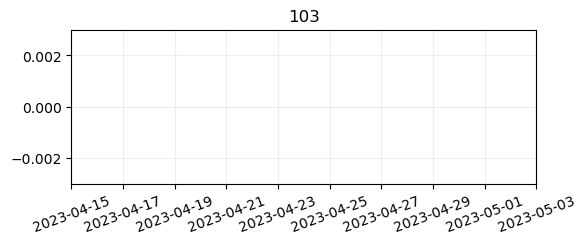

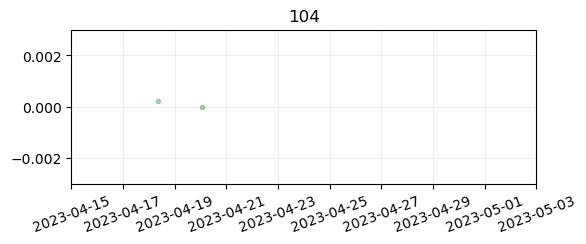

105


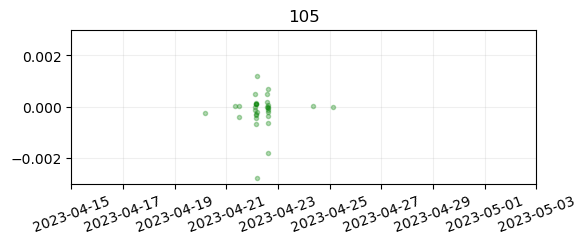

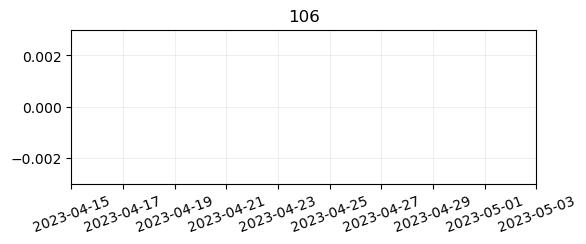

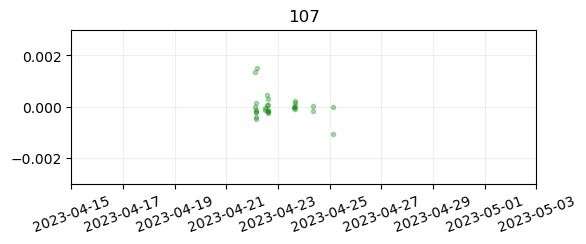

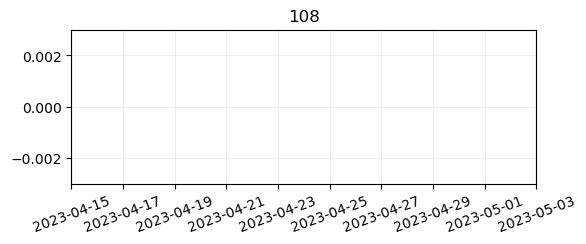

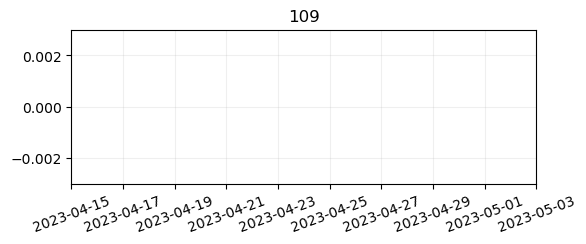

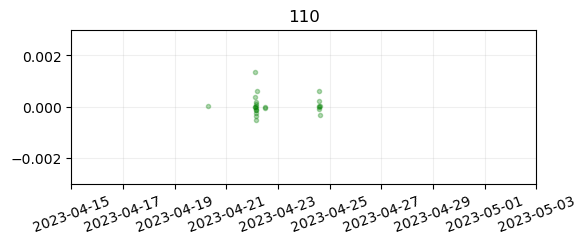

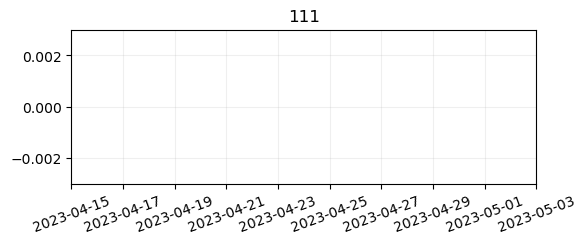

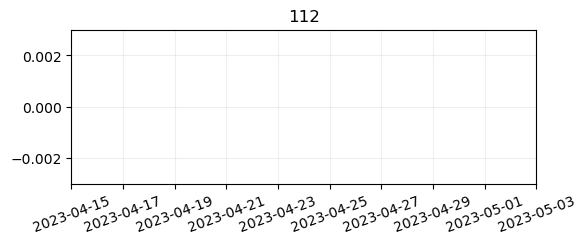

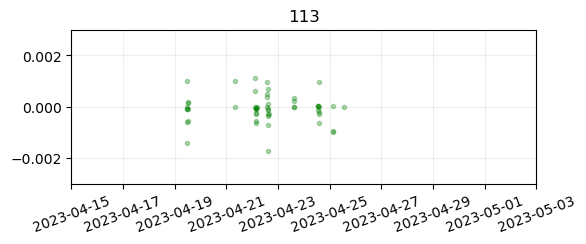

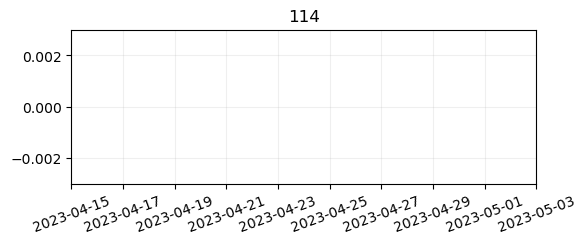

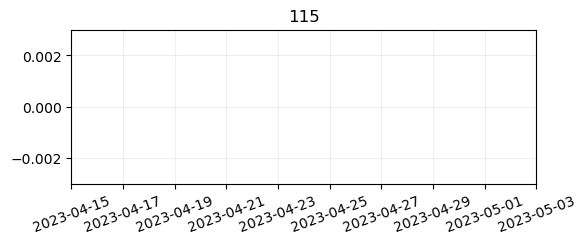

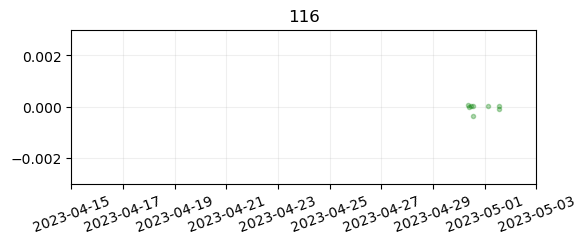

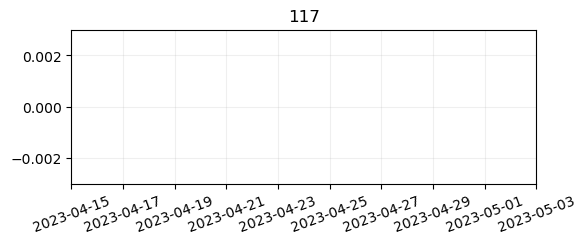

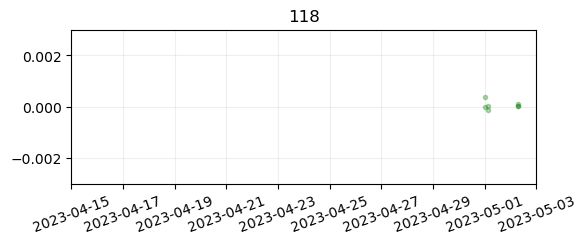

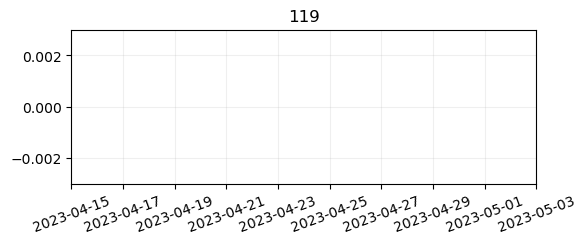

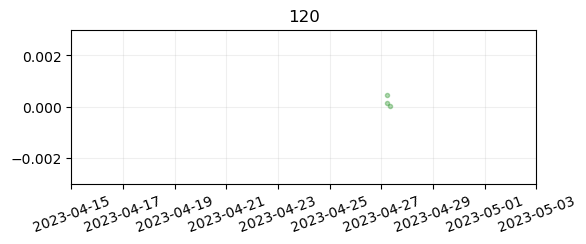

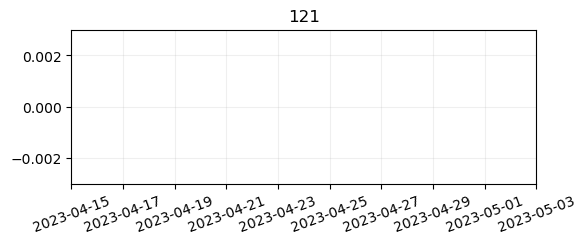

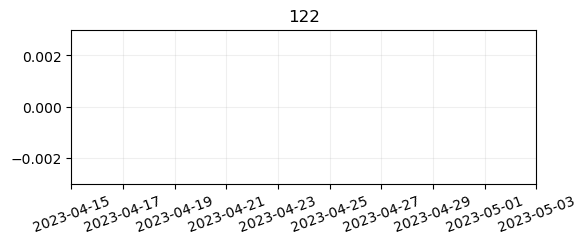

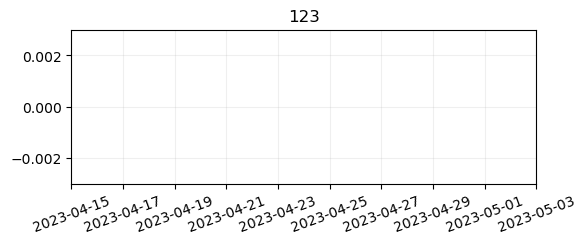

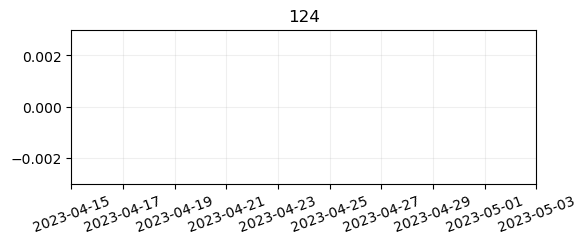

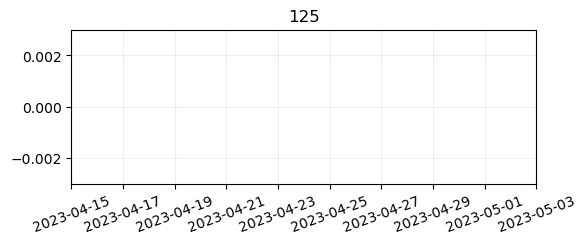

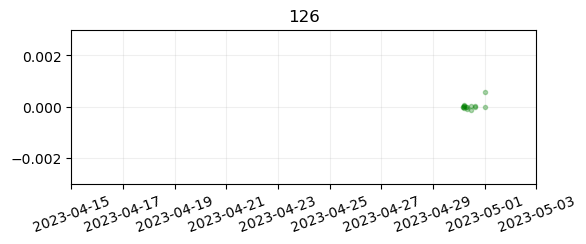

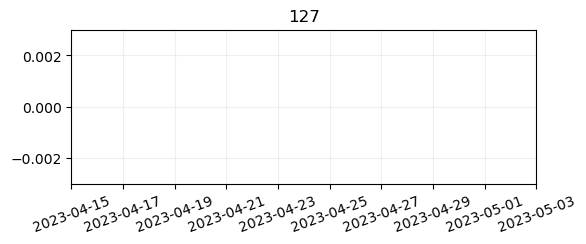

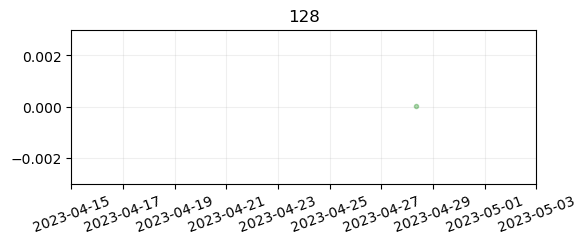

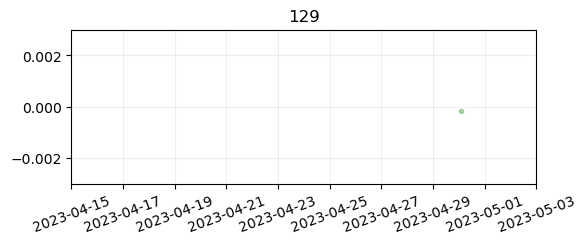

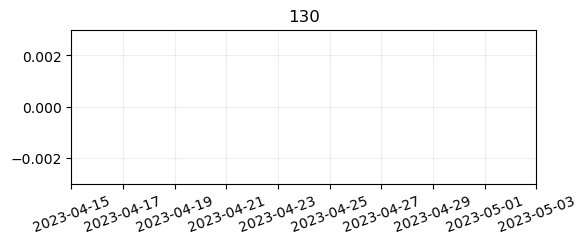

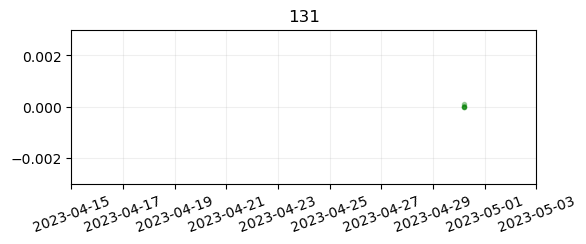

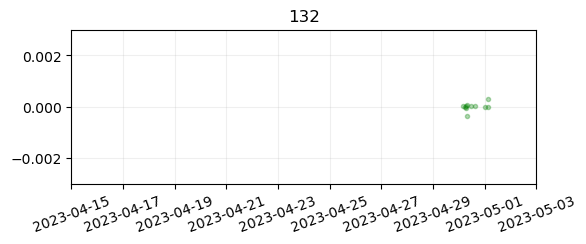

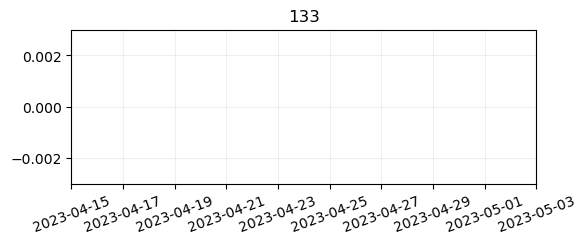

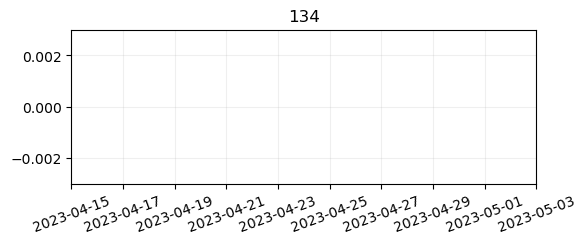

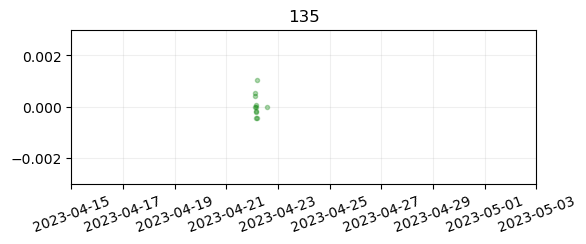

In [155]:
# find ouliers
import matplotlib.dates as mdates
time_stamps_num = mdates.date2num(['2023-04-15','2023-05-03'])

for i in range(30,len(dChldt_ship_ALL)):
    if np.sum(np.abs(dChldt_ship_ALL[i])>2e-3):
        print(i)
    
    plt.figure(figsize=(6,2))
    plt.plot(time_ALL[i],dChldt_ship_ALL[i],'g.',alpha=0.3)
    plt.title(i)
    plt.xticks(rotation=20)
    plt.xlim(min(time_stamps_num), max(time_stamps_num))
    plt.ylim(-3e-3,3e-3)
    plt.grid(alpha=0.2)
    plt.show()
    plt.close()